# LAB 1. GRADIENT DESCENT

## 1. Apply the gradient descent method to minimize the Rosenbrock function

$$f(x) = 100*(x_2-x_1^2)^2 + (1-x_1)^2 $$

Initial condition of $$ x^0 = (-2, 2)^T $$


In [86]:
import numpy as np
import time
import matplotlib.pyplot as plt

In [87]:
def calculate_objective(x):
    x_1, x_2 = x
    return 100*(x_2-(x_1)**2)**2 + (1-x_1)**2

def compute_gradient(x):
    x_1, x_2 = x
    df_dx_1 = -400*x_1*(x_2-x_1**2) - 2*(1-x_1)
    df_dx_2 = 200*(x_2-x_1**2)
    return np.array([df_dx_1, df_dx_2])

def gradient_descent(x_0, gamma, norm = 0.0001, iterations = 1000):
    x = x_0
    results = []
    start_time = time.time()
    i = 0
    for iteration in range(iterations):
        i +=1
        f = calculate_objective(x)
        results.append(f)
        gradient = compute_gradient(x)
        if np.linalg.norm(gradient) < norm:
            break

        x = x-gamma*gradient

    running_time = time.time() - start_time

    return x, results, i, running_time

Gamma = 0.1
Iteration = 1001
Running time = 0.008003711700439453
Results = [nan nan]

Gamma = 0.01
Iteration = 1001
Running time = 0.006999492645263672
Results = [nan nan]

Gamma = 0.001
Iteration = 1001
Running time = 0.007022857666015625
Results = [-0.26172728  0.07378466]



C:\Users\valer\AppData\Local\Temp\ipykernel_19620\1520302897.py:3: RuntimeWarning: overflow encountered in scalar power
  return 100*(x_2-(x_1)**2)**2 + (1-x_1)**2
C:\Users\valer\AppData\Local\Temp\ipykernel_19620\1520302897.py:7: RuntimeWarning: overflow encountered in scalar power
  df_dx_1 = -400*x_1*(x_2-x_1**2) - 2*(1-x_1)
C:\Users\valer\AppData\Local\Temp\ipykernel_19620\1520302897.py:8: RuntimeWarning: overflow encountered in scalar power
  df_dx_2 = 200*(x_2-x_1**2)
C:\Users\valer\AppData\Local\Temp\ipykernel_19620\1520302897.py:3: RuntimeWarning: invalid value encountered in scalar subtract
  return 100*(x_2-(x_1)**2)**2 + (1-x_1)**2
C:\Users\valer\AppData\Local\Temp\ipykernel_19620\1520302897.py:7: RuntimeWarning: invalid value encountered in scalar subtract
  df_dx_1 = -400*x_1*(x_2-x_1**2) - 2*(1-x_1)
C:\Users\valer\AppData\Local\Temp\ipykernel_19620\1520302897.py:8: RuntimeWarning: invalid value encountered in scalar subtract
  df_dx_2 = 200*(x_2-x_1**2)
C:\Users\valer\App

<Figure size 640x480 with 0 Axes>

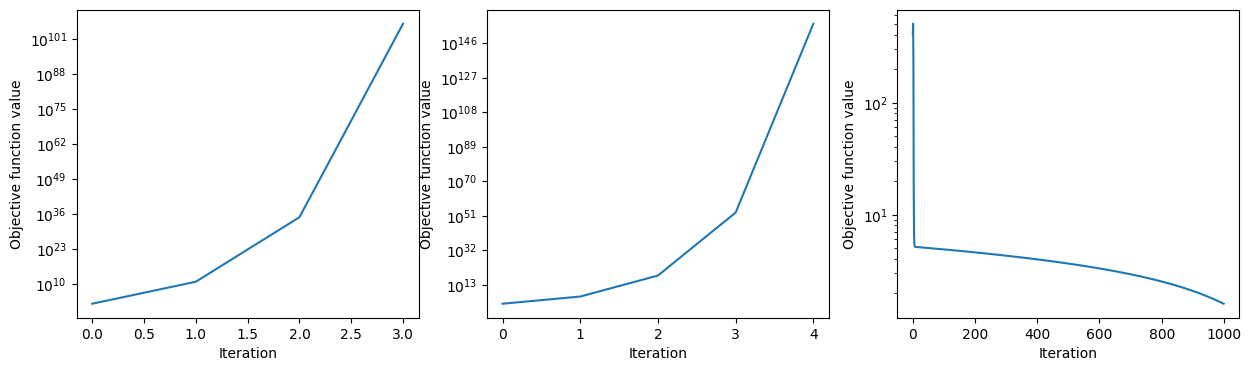

In [88]:
x_0 = np.array([-2.0, 2.0])
gammas = [0.1, 0.01, 0.001]
plt.figure()
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for i, gamma in enumerate(gammas):
    x, results, iteration, running_time = gradient_descent(x_0, gamma)
    print(f"Gamma = {gamma}\nIteration = {iteration + 1}\nRunning time = {running_time}\nResults = {x}\n")
    ax[i].plot(results, label=f"Gamma = {gamma}")
    ax[i].set_yscale('log')
    ax[i].set_xlabel("Iteration")
    ax[i].set_ylabel("Objective function value")

plt.show()



## Analyze the convergence rate of the gradient descent depending on the step size. ##

With steps of 0.1 and 0.01, convergence was not achieved because the step size was too large. At the same time, with a step size of 0.001, there was also no convergence after 1000 iterations because the step size was too small, so this method is not optimal; many more iterations would be needed to reach the minimum.


## Apply the gradient descent method to the Least Squares Estimation ##

$$ f(x) = \frac{1}{2m} \sum_{i=1}^{m} \left( \sum_{j=1}^{n} a_{ij}x_j - b_i \right)^2 = \frac{1}{2m} \|\mathbf{Ax} - \mathbf{b}\|^2 $$

In [89]:
def calculate_objective(x, A, b):
    m = A.shape[0]
    return (1 / (2*m)) * np.sum((A@x - b)**2)

def compute_gradient(x, A, b):
    m = A.shape[0]
    return (1/m) * A.T@(A@x - b)

def gradient_descent(x_0, A, b, gamma, iterations = 50):
    x = x_0
    results = []
    start_time = time.time()
    for iteration in range(iterations):
        f = calculate_objective(x, A, b)
        results.append(f)
        x = x-gamma*compute_gradient(x, A, b)

    running_time = time.time() - start_time

    return x, results, running_time

Gamma = 0.1
Running time = 0.0010004043579101562
Results = [-0.8509015  -0.78813281 -0.93737248  1.03946764 -0.56928357]

Gamma = 0.25046814355923314
Running time = 0.0010020732879638672
Results = [-0.90435563 -1.12747219 -1.01416473  0.98247601 -1.09265739]

Gamma = 0.012296332437390511
Running time = 0.001001596450805664
Results = [-0.238142   -0.16535515 -0.43792141  0.31532323 -0.06778311]



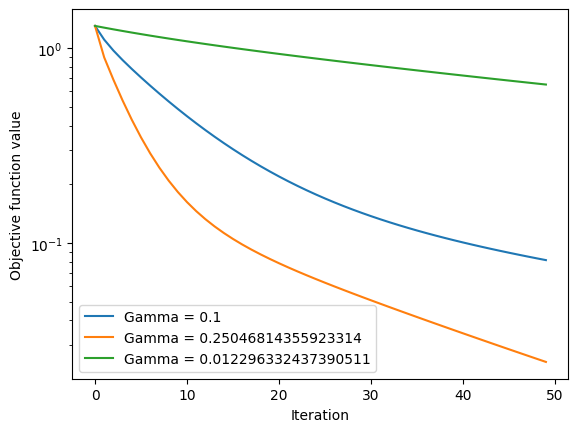

In [90]:
m = 5
n = 5
A = np.random.randn(m, n)
b = np.random.randn(m)
x_0 = np.zeros(n)

beta = (1/m) * (np.linalg.norm(A, 2)**2)
L = (1/m) * (np.linalg.norm(A.T@A, 2) * 20 + np.linalg.norm(A.T @ b, 2))

gammas = [0.1, 1/beta, 1/L]

plt.figure()

for i, gamma in enumerate(gammas):
    x, results, running_time = gradient_descent(x_0, A, b, gamma)
    print(f"Gamma = {gamma}\nRunning time = {running_time}\nResults = {x}\n")
    plt.plot(results, label=f"Gamma = {gamma}")

plt.yscale('log')
plt.xlabel("Iteration")
plt.ylabel("Objective function value")
plt.legend()
plt.show()

The lowest speed was shown by the step of 1/L, while the most optimal speed is 1/Beta. The step of 0.1, which we took as standard, moves faster than 1/L, but slower than the step of 1/Beta.

## 3. Apply the gradient descent method to the Solving Fixed Point Problems. ##

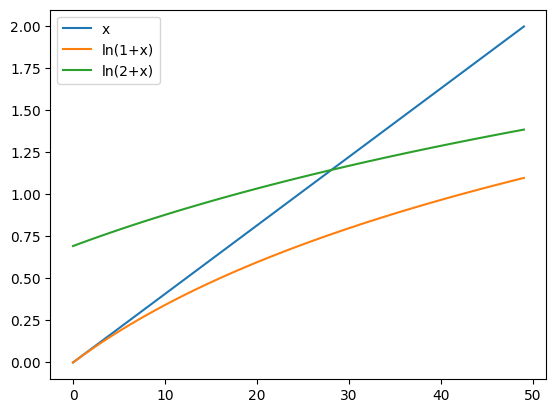

In [91]:
x = np.linspace(0, 2)

y_1 = x
y_2 = np.log(1+x)
y_3 = np.log(2+x)

plt.figure()
plt.plot(y_1, label="x")
plt.plot(y_2, label="ln(1+x)")
plt.plot(y_3, label="ln(2+x)")

plt.legend()
plt.show()

Approximate fixed points for both functions for ln(1+x) = 0, for ln(2+x) = 1.15

In [92]:
def calculate_objective_g_1(x):
    return (1/2) * (x - np.log(1+x))**2

def calculate_objective_g_2(x):
    return (1/2) * (x - np.log(2+x))**2

def compute_gradient_g_1(x):
    return (x - np.log(1+x)) * (1 - (1/(1+x)))

def compute_gradient_g_2(x):
    return (x - np.log(2+x)) * (1 - (1/(2+x)))

def gradient_descent(x_0, g, grad, gamma, iterations = 100):
    x = x_0
    x_values = []
    f_values = []
    start_time = time.time()
    for iteration in range(iterations):
        x_values.append(x)
        f_values.append(g(x))
        x = x-gamma*grad(x)

    running_time = time.time() - start_time

    return x_values, f_values, running_time

In [93]:
g_1_sd = (1 - 1/(1+x))**2 + (x - np.log(1+x)) * (1/(1+x)**2)
g_2_sd = (1 - 1/(2+x))**2 + (x - np.log(2+x)) * (1/(2+x)**2)

L1 = 0.5445986345924323
L2 = 0.6008566024300068
Results for g1:
Gamma = 1.836214666142859
Running time = 0.0

Iteration = 0
x = 2
g(x) = 0.4062499030700715
Iteration = 10
x = 0.29433989634409036
g(x) = 0.0006602637754132413
Iteration = 20
x = 0.199788609757681
g(x) = 0.00015564172978192376
Iteration = 30
x = 0.15918102593382408
g(x) = 6.574928150758425e-05
Iteration = 40
x = 0.13557849806338967
g(x) = 3.558546962977322e-05
Iteration = 50
x = 0.11978430230570099
g(x) = 2.2099433020062457e-05
Iteration = 60
x = 0.10830672449157694
g(x) = 1.4978765429483833e-05
Iteration = 70
x = 0.09950039583555777
g(x) = 1.078571245945464e-05
Iteration = 80
x = 0.09247818516596211
g(x) = 8.118456034853002e-06
Iteration = 90
x = 0.08671522226734216
g(x) = 6.32126474689456e-06

Results for g2:
Gamma = 1.664290607702008
Running time = 0.0

Iteration = 0
x = 2
g(x) = 0.18831730559662163
Iteration = 10
x = 1.1461933422582884
g(x) = 3.4424949178010916e-15
Iteration = 20
x = 1.146193220620624
g(x) = 3.97610548

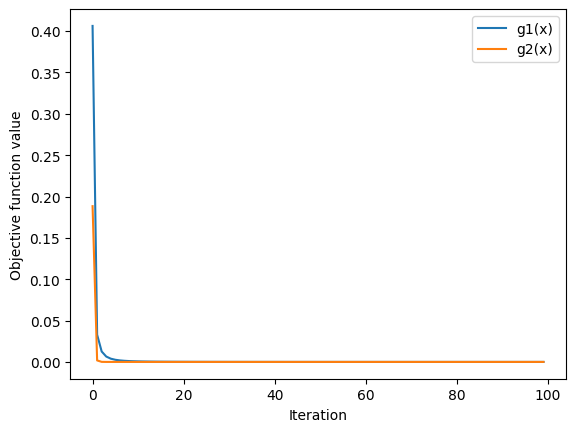

In [94]:
L_1 = np.max(np.abs(g_1_sd))
L_2 = np.max(np.abs(g_2_sd))
print(f"L1 = {L_1}")
print(f"L2 = {L_2}")

gamma_1 = 1/L_1
gamma_2 = 1/L_2
x_0 = 2
x_values_1, f_values_1, running_time_1 = gradient_descent(x_0, calculate_objective_g_1, compute_gradient_g_1, gamma_1)

print("Results for g1:")
print(f"Gamma = {gamma_1}\nRunning time = {running_time_1}\n")
for i in range (0 ,100 ,10):
    print(f"Iteration = {i}\nx = {x_values_1[i]}\ng(x) = {f_values_1[i]}")

x_values_2, f_values_2, running_time_2 = gradient_descent(x_0, calculate_objective_g_2, compute_gradient_g_2, gamma_2)

print("\nResults for g2:")
print(f"Gamma = {gamma_2}\nRunning time = {running_time_2}\n")
for i in range (0 ,100 ,10):
    print(f"Iteration = {i}\nx = {x_values_2[i]}\ng(x) = {f_values_2[i]}")


plt.figure()
plt.plot(f_values_1, label="g1(x)")
plt.plot(f_values_2, label="g2(x)")
plt.xlabel("Iteration")
plt.ylabel("Objective function value")
plt.legend()
plt.show()

## What do you observe about the rates of convergence of the method in both cases? Can you explain this difference? ##
For g_2, the algorithm reached its minimum at the 30th iteration, while for g_1, the algorithm did not reach its minimum point but came as close to it as possible.

1. Gradient descent is an optimisation algorithm for finding the local minimum of a differentiable function. Its geometric interpretation is that the gradient indicates the direction of the steepest growth of the function. Therefore, if we move in the opposite direction, we descend the shortest path to the minimum point.
2. The function must be differentiable and convex.
3. A function is convex if we can connect any two points and remain within the function.
For a convex function, any local minimum is global. Therefore, gradient descent will definitely descend to the minimum.

5. It comes from Hessian (matrix of second derivatives)
6. Beta is the most accurate constant for a specific quadratic form.